# S&P 500 Options Analytics

**Docker image**: `ml4t`

## Purpose

Profile the AlgoSeek S&P 500 options analytics dataset for an 8-symbol 2020 EDA
slice — chain structure, implied-volatility surfaces, data quality, and an early
look at the predictive content that motivates the options case studies.

## Learning Objectives

- Read an option chain and locate strikes, expirations, and call/put pairs.
- Construct and visualize an implied-volatility smile, term structure, and surface.
- Apply IV-convergence and Greeks-validity filters to clean options data.
- Quantify a baseline IV-change → forward-return relationship in the cross section.

## Book Reference

Chapter 2 §2.2 (asset-class market data landscape — derivatives).

## Prerequisites

- Familiarity with daily OHLC equity data (`01_us_equities_eda`).
- The AlgoSeek S&P 500 options EDA parquet at `$ML4T_DATA_PATH/sp500_options/`
  (8 representative underlyings: AAPL, AMZN, BA, GOOGL, JPM, KO, MSFT, XOM).
- The S&P 500 daily-bar parquet covering the same 2020 window.

Loaders used:

| Dataset | Loader | Coverage |
|---------|--------|----------|
| S&P 500 options (EDA slice) | `load_sp500_options_eda()` | 2020, 8 underlyings |
| S&P 500 daily prices | `load_sp500_daily_bars()` | 2020, same 8 underlyings |

In [1]:
"""S&P 500 Options Analytics — options chain structure, volatility surfaces, and data quality."""

import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_sp500_daily_bars, load_sp500_options_eda

In [2]:
DAILY_START_DATE = "2020-01-01"

## 1. Options Primer for ML Practitioners

Before diving into the data, let's establish the key concepts that make options
data different from—and complementary to—spot market data.

### 1.1 What is an Option?

An option is a **derivative contract** that gives the holder the right (but not
obligation) to buy or sell an underlying asset at a specified price (strike)
by a specified date (expiration).

| Type | Right | Profitable When |
|------|-------|-----------------|
| **Call** | Buy at strike | Underlying rises above strike |
| **Put** | Sell at strike | Underlying falls below strike |

### 1.2 Why Options Data Matters for ML

Options prices embed **forward-looking information** that spot prices don't:

1. **Implied Volatility (IV)** - Market's expectation of future volatility
2. **IV Skew** - Relative demand for downside vs upside protection
3. **Term Structure** - How expectations change across time horizons
4. **Greeks** - Sensitivities that quantify risk exposures

This information can predict:
- Future realized volatility
- Underlying price movements (via order flow/positioning)
- Tail risk events (via skew)

### 1.3 Moneyness: ITM, ATM, OTM

Moneyness describes how an option's strike relates to the current spot price:

| Moneyness | Call (Strike vs Spot) | Put (Strike vs Spot) | Characteristics |
|-----------|----------------------|---------------------|-----------------|
| **ITM** (In-the-money) | Strike < Spot | Strike > Spot | Has intrinsic value |
| **ATM** (At-the-money) | Strike ≈ Spot | Strike ≈ Spot | Highest time value |
| **OTM** (Out-of-the-money) | Strike > Spot | Strike < Spot | Pure time value |

We typically express moneyness as: **Strike / Spot** (or its log)
- Moneyness = 1.0 → ATM
- Moneyness < 1.0 → ITM call / OTM put
- Moneyness > 1.0 → OTM call / ITM put

### 1.4 Option Value Components

An option's price decomposes into intrinsic value (immediate exercise payoff) and
time value (the remainder, reflecting optionality):

$$\text{Price} = \text{Intrinsic} + \text{Time}$$

$$\text{Intrinsic}_{\text{call}} = \max(0,\; S - K), \qquad \text{Intrinsic}_{\text{put}} = \max(0,\; K - S)$$

$$\text{Time} = \text{Price} - \text{Intrinsic}$$

Time value reflects:
- Time remaining until expiration
- Expected volatility (IV)
- Interest rates and dividends

## 2. Dataset Overview

### 2.1 Data Schema

| Field | Type | Description |
|-------|------|-------------|
| **Identifiers** | | |
| `timestamp` | Date | Trading date (observation date, EOD snapshot) |
| `symbol` | String | Underlying ticker (e.g., "AAPL", "MSFT") |
| `expiration` | Date | Option expiration date |
| `strike` | Float64 | Strike price in USD |
| `call_put` | String | "C" for call, "P" for put |
| **Prices** | | |
| `bid` | Float64 | Best bid price at close |
| `ask` | Float64 | Best ask price at close |
| `mid_price` | Float64 | Mid-market price: (bid + ask) / 2 |
| `underlying_price` | Float64 | Underlying stock close price |
| **Time** | | |
| `days_to_maturity` | Int32 | Calendar days until expiration |
| **Greeks** | | |
| `delta` | Float64 | ∂V/∂S - Price sensitivity to underlying |
| `gamma` | Float64 | ∂²V/∂S² - Delta sensitivity to underlying |
| `theta` | Float64 | ∂V/∂t - Time decay ($/day, typically negative) |
| `vega` | Float64 | ∂V/∂σ - Sensitivity to volatility |
| `rho` | Float64 | ∂V/∂r - Sensitivity to interest rates |
| **Volatility** | | |
| `implied_vol` | Float64 | Black-Scholes implied volatility |
| `iv_convergence` | String | IV solver status (quality indicator) |

### 2.2 IV Convergence Codes

The `iv_convergence` field indicates IV computation quality:

| Code | Meaning | Use in Analysis |
|------|---------|-----------------|
| `Converged` | IV solver converged normally | [OK] Highest quality |
| `SmallBid_FlatExtrapol` | Small bid, IV extrapolated | WARNING: Use with caution |
| `IntrVal_FlatExtrapol` | Deep ITM, IV extrapolated | WARNING: Use with caution |
| `IntrVal_PutCallPair` | IV from put-call parity | [OK] Usually reliable |
| `Failed` | IV solver did not converge | [FAIL] Exclude from analysis |

**Best practice**: Filter for `iv_convergence == "Converged"` for clean analysis.

In [3]:
options = load_sp500_options_eda(
    start_date="2020-01-01",
    end_date="2020-12-31",
    include_greeks=True,
)

print("=== S&P 500 Options Dataset ===")
print(f"Total rows: {len(options):,}")
print(f"Columns: {len(options.columns)}")
print(f"Date range: {options['timestamp'].min()} to {options['timestamp'].max()}")
print(f"Underlyings: {sorted(options['symbol'].unique().to_list())}")

=== S&P 500 Options Dataset ===
Total rows: 5,158,876
Columns: 21
Date range: 2020-01-02 to 2020-12-31
Underlyings: ['AAPL', 'AMZN', 'BA', 'GOOGL', 'JPM', 'KO', 'MSFT', 'XOM']


In [4]:
daily = load_sp500_daily_bars(
    symbols=sorted(options["symbol"].unique().to_list()),
    start_date=DAILY_START_DATE,
    end_date="2020-12-31",
)

print("\n=== S&P 500 Daily Prices ===")
print(f"Total rows: {len(daily):,}")
print(f"Symbols: {daily['symbol'].n_unique()}")
print(f"Date range: {daily['timestamp'].min()} to {daily['timestamp'].max()}")


=== S&P 500 Daily Prices ===
Total rows: 2,024
Symbols: 8
Date range: 2020-01-02 to 2020-12-31


In [5]:
# Quick schema preview
print("\n=== Options Schema ===")
options.head(3)


=== Options Schema ===


symbol,call_put,option_style,strike,expiration,years_to_maturity,days_to_maturity,underlying_price,bid,ask,mid_price,implied_vol,theo_price,delta,gamma,theta,vega,rho,iv_convergence,year,timestamp
str,str,str,f64,date,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,date
"""AAPL""","""C""","""A""",200.0,2020-01-03,0.0027322,1,300.59,98.4,102.15,100.275,0.27617,100.59853,1.0,0.0,-0.00856,0.0,0.00546,"""IntrVal_FlatExtrapol""",2020,2020-01-02
"""AAPL""","""C""","""A""",205.0,2020-01-03,0.0027322,1,300.59,93.4,97.2,95.3,0.27617,95.59875,1.0,0.0,-0.00877,0.0,0.0056,"""IntrVal_FlatExtrapol""",2020,2020-01-02
"""AAPL""","""C""","""A""",210.0,2020-01-03,0.0027322,1,300.59,88.4,92.2,90.3,0.27617,90.59896,1.0,0.0,-0.00899,0.0,0.00574,"""IntrVal_FlatExtrapol""",2020,2020-01-02


## 3. Option Chain Structure

An **option chain** is the full set of options available for one underlying on one day.
It spans multiple dimensions:
- **Strikes**: Many price levels around the current spot
- **Expirations**: Multiple dates from days to years out
- **Types**: Calls and puts at each strike/expiration

This creates a 3D grid: `(strike × expiration × call_put)`

In [6]:
# Options per symbol per day - how dense are the chains?
options_per_symbol = options.group_by(["timestamp", "symbol"]).agg(
    [
        pl.len().alias("n_options"),
        (pl.col("call_put") == "C").sum().alias("n_calls"),
        (pl.col("call_put") == "P").sum().alias("n_puts"),
        pl.col("strike").n_unique().alias("n_strikes"),
        pl.col("expiration").n_unique().alias("n_expirations"),
    ]
)

print("=== Option Chain Density (per symbol per day) ===")
options_per_symbol.select(["n_options", "n_strikes", "n_expirations"]).describe()

=== Option Chain Density (per symbol per day) ===


statistic,n_options,n_strikes,n_expirations
str,f64,f64,f64
"""count""",2024.0,2024.0,2024.0
"""null_count""",0.0,0.0,0.0
"""mean""",2548.851779,165.240613,16.118083
"""std""",2072.356814,133.886019,2.276791
"""min""",636.0,52.0,12.0
"""25%""",1014.0,74.0,14.0
"""50%""",1766.0,105.0,16.0
"""75%""",3322.0,242.0,18.0
"""max""",8692.0,572.0,22.0


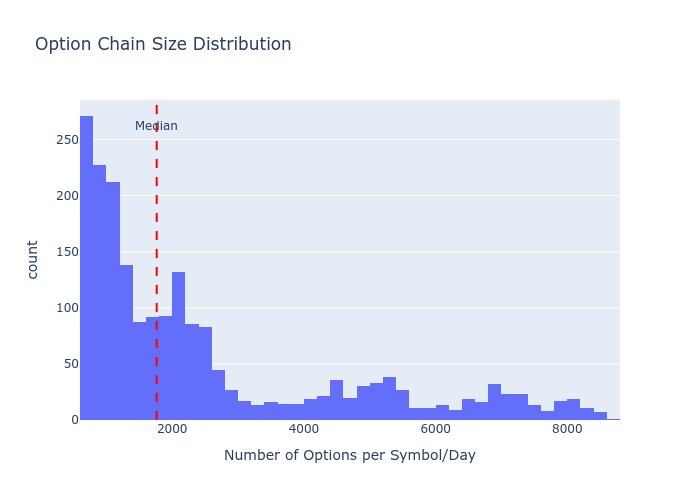

In [7]:
# Visualize: Distribution of chain sizes
fig = px.histogram(
    options_per_symbol.to_pandas(),
    x="n_options",
    nbins=50,
    title="Option Chain Size Distribution",
    labels={"n_options": "Number of Options per Symbol/Day", "count": "Frequency"},
)
median_options = float(options_per_symbol["n_options"].median())
fig.add_vline(x=median_options, line_dash="dash", line_color="red")
fig.add_annotation(x=median_options, y=0.95, yref="paper", text="Median", showarrow=False)
fig.update_layout(showlegend=False)
fig.show()

### 3.1 Single Symbol Deep Dive: AAPL

Let's examine one complete option chain to understand the structure.

In [8]:
# AAPL on a specific date
sample_date = options["timestamp"].max()
aapl_day = options.filter((pl.col("symbol") == "AAPL") & (pl.col("timestamp") == sample_date))

spot = aapl_day["underlying_price"][0]

print(f"=== AAPL Option Chain ({sample_date}) ===")
print(f"Underlying price: ${spot:.2f}")
print(f"Total options: {len(aapl_day):,}")
print(f"  Calls: {aapl_day.filter(pl.col('call_put') == 'C').height:,}")
print(f"  Puts: {aapl_day.filter(pl.col('call_put') == 'P').height:,}")
print(f"Expirations: {aapl_day['expiration'].n_unique()}")
print(f"Strikes: {aapl_day['strike'].n_unique()}")
print(f"Strike range: ${aapl_day['strike'].min():.2f} - ${aapl_day['strike'].max():.2f}")

=== AAPL Option Chain (2020-12-31) ===
Underlying price: $132.59
Total options: 2,194
  Calls: 1,097
  Puts: 1,097
Expirations: 18
Strikes: 163
Strike range: $18.75 - $250.00


In [9]:
# Expiration breakdown
exp_breakdown = (
    aapl_day.group_by("expiration")
    .agg([pl.len().alias("n_options"), pl.col("strike").n_unique().alias("n_strikes")])
    .sort("expiration")
)
print("\n=== AAPL Expirations ===")
exp_breakdown.head(10)


=== AAPL Expirations ===


expiration,n_options,n_strikes
date,u32,u32
2020-12-31,120,60
2021-01-08,134,67
2021-01-15,230,115
2021-01-22,124,62
2021-01-29,124,62
2021-02-05,104,52
2021-02-12,58,29
2021-02-19,84,42
2021-03-19,134,67


### 3.2 Option Chain Heatmap

Visualize the entire chain as a heatmap: strikes on y-axis, expirations on x-axis,
colored by implied volatility. This reveals the **volatility surface** structure.

In [10]:
# Prepare data for heatmap - calls only, converged IV, reasonable moneyness
aapl_calls = (
    aapl_day.filter(
        (pl.col("call_put") == "C")
        & (pl.col("iv_convergence") == "Converged")
        & (pl.col("implied_vol") > 0)
        & (pl.col("implied_vol") < 2.0)  # Filter outliers
    )
    .with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
    .filter(pl.col("moneyness").is_between(0.7, 1.3))  # Focus on tradeable range
)

# Create pivot for heatmap
heatmap_data = (
    aapl_calls.select(["strike", "expiration", "implied_vol"])
    .sort(["expiration", "strike"])
    .to_pandas()
    .pivot(index="strike", columns="expiration", values="implied_vol")
)

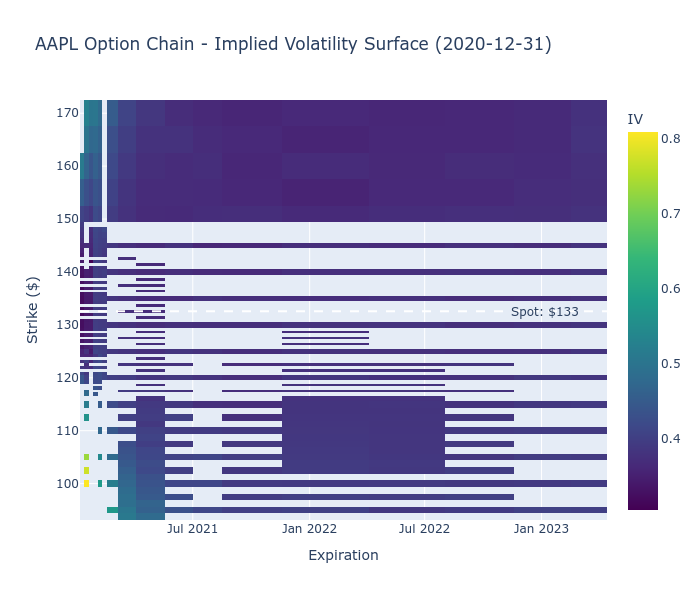

In [11]:
fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=[str(c) for c in heatmap_data.columns],
        y=heatmap_data.index,
        colorscale="Viridis",
        colorbar=dict(title="IV"),
    )
)

spot_float = float(spot)
fig.add_hline(y=spot_float, line_dash="dash", line_color="white")
fig.add_annotation(
    y=spot_float, x=0.95, xref="paper", text=f"Spot: ${spot_float:.0f}", showarrow=False
)

fig.update_layout(
    title=f"AAPL Option Chain - Implied Volatility Surface ({sample_date})",
    xaxis_title="Expiration",
    yaxis_title="Strike ($)",
    height=600,
)
fig.show()

**Reading the heatmap:**
- Horizontal slice at one strike → Term structure (how IV varies with expiration)
- Vertical slice at one expiration → IV smile/skew (how IV varies with strike)
- Darker colors (lower IV) typically at ATM; lighter (higher IV) at wings

## 4. Volatility Surface Analysis

The **implied volatility surface** is the core representation for options analytics.
It captures how IV varies across two dimensions:
1. **Moneyness** (strike relative to spot) → IV smile/skew
2. **Time to expiration** → IV term structure

### 4.1 IV Smile and Skew

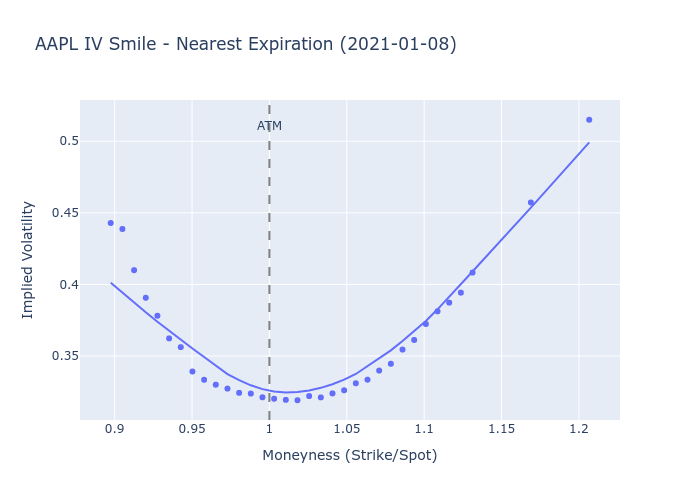

In [12]:
# IV smile for nearest expiration
nearest_exp = aapl_calls["expiration"].min()
aapl_smile = aapl_calls.filter(pl.col("expiration") == nearest_exp).sort("strike")

fig = px.scatter(
    aapl_smile.to_pandas(),
    x="moneyness",
    y="implied_vol",
    title=f"AAPL IV Smile - Nearest Expiration ({nearest_exp})",
    labels={"moneyness": "Moneyness (Strike/Spot)", "implied_vol": "Implied Volatility"},
    trendline="lowess",
)
fig.add_vline(x=1.0, line_dash="dash", line_color="gray")
fig.add_annotation(x=1.0, y=0.95, yref="paper", text="ATM", showarrow=False)
fig.show()

**IV Smile/Skew interpretation:**
- **Smile**: IV higher for both OTM puts (left) and OTM calls (right) vs ATM
- **Skew**: Asymmetric - OTM puts typically have higher IV than OTM calls
- **Why?** Demand for downside protection (crash insurance) exceeds upside speculation

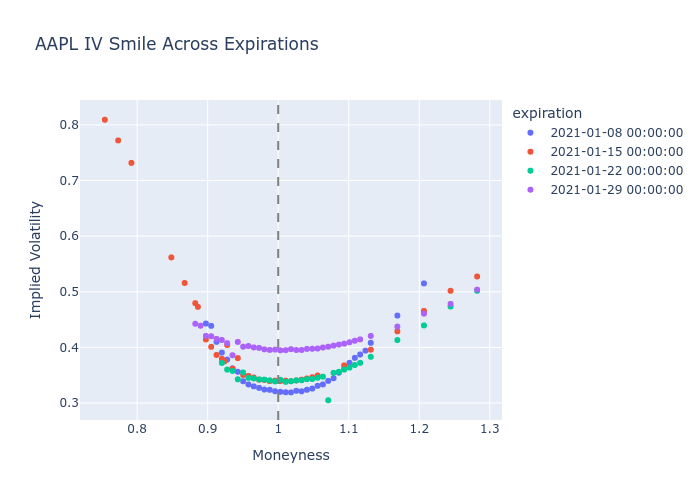

In [13]:
# Compare smile across multiple expirations
expirations = sorted(aapl_calls["expiration"].unique().to_list())[:4]  # First 4

smile_data = aapl_calls.filter(pl.col("expiration").is_in(expirations))

fig = px.scatter(
    smile_data.to_pandas(),
    x="moneyness",
    y="implied_vol",
    color="expiration",
    title="AAPL IV Smile Across Expirations",
    labels={"moneyness": "Moneyness", "implied_vol": "Implied Volatility"},
)
fig.add_vline(x=1.0, line_dash="dash", line_color="gray")
fig.show()

### 4.2 IV Term Structure

How does ATM IV vary across expirations?

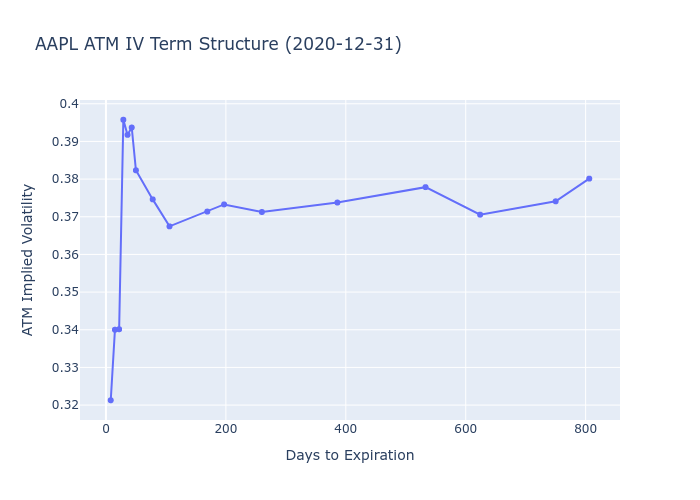

In [14]:
# ATM IV term structure (moneyness 0.98-1.02)
atm_term = (
    aapl_calls.filter(pl.col("moneyness").is_between(0.98, 1.02))
    .group_by("expiration")
    .agg(
        [
            pl.col("implied_vol").mean().alias("iv_atm"),
            pl.col("days_to_maturity").first().alias("days"),
        ]
    )
    .sort("expiration")
)

fig = px.line(
    atm_term.to_pandas(),
    x="days",
    y="iv_atm",
    markers=True,
    title=f"AAPL ATM IV Term Structure ({sample_date})",
    labels={"days": "Days to Expiration", "iv_atm": "ATM Implied Volatility"},
)
fig.show()

**Term structure shapes:**
- **Contango** (upward sloping): Near-term calm, uncertainty further out
- **Backwardation** (downward sloping): Near-term stress/event expected
- **Flat**: Consistent expectations across horizons

### 4.3 3D Volatility Surface

Combine moneyness and time dimensions into a single surface visualization.

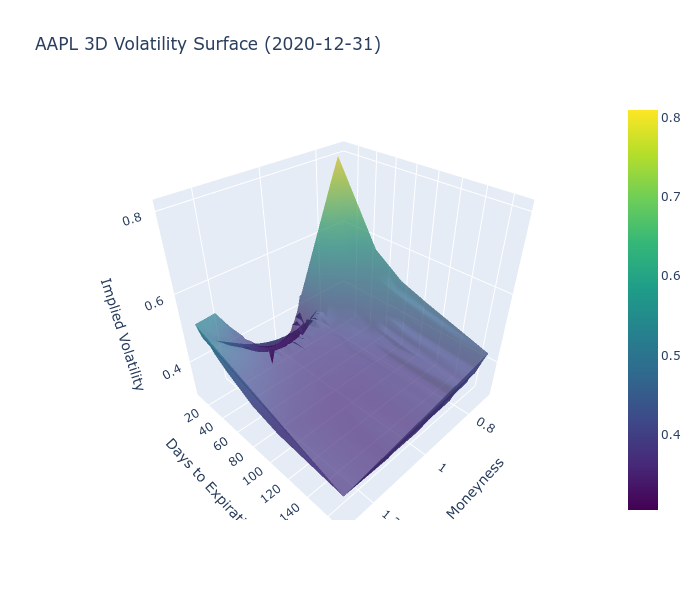

In [15]:
# Prepare surface data
surface_data = (
    aapl_calls.filter(pl.col("days_to_maturity") <= 180)  # Focus on <6 months
    .select(["moneyness", "days_to_maturity", "implied_vol"])
    .to_pandas()
)

# Create 3D surface
fig = go.Figure(
    data=[
        go.Mesh3d(
            x=surface_data["moneyness"],
            y=surface_data["days_to_maturity"],
            z=surface_data["implied_vol"],
            intensity=surface_data["implied_vol"],
            colorscale="Viridis",
            opacity=0.7,
        )
    ]
)

fig.update_layout(
    title=f"AAPL 3D Volatility Surface ({sample_date})",
    scene=dict(
        xaxis_title="Moneyness",
        yaxis_title="Days to Expiration",
        zaxis_title="Implied Volatility",
    ),
    height=600,
)
fig.show()

## 5. Cross-Sectional Analysis

How does ATM IV differ across the eight underlyings on a single day? The same
logic scales to the full S&P 500 universe — here we keep the comparison
tractable on the EDA slice.

In [16]:
# Compute ATM IV for all symbols on sample date
converged = options.filter(pl.col("iv_convergence") == "Converged")

cross_section = (
    converged.filter(pl.col("timestamp") == sample_date)
    .with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
    .filter(pl.col("moneyness").is_between(0.98, 1.02))
    .filter(pl.col("call_put") == "C")
    .group_by("symbol")
    .agg(
        [
            pl.col("implied_vol").mean().alias("iv_atm"),
            pl.col("underlying_price").first().alias("price"),
        ]
    )
    .sort("iv_atm", descending=True)
)

print(f"=== Cross-Sectional ATM IV ({sample_date}) ===")
print(f"Symbols: {len(cross_section)}")
print(f"IV range: {cross_section['iv_atm'].min():.1%} - {cross_section['iv_atm'].max():.1%}")
print(f"IV median: {cross_section['iv_atm'].median():.1%}")

=== Cross-Sectional ATM IV (2020-12-31) ===
Symbols: 8
IV range: 22.1% - 46.1%
IV median: 31.7%


In [17]:
# Highest IV names
print("\n=== Highest IV Names ===")
cross_section.head(10)


=== Highest IV Names ===


symbol,iv_atm,price
str,f64,f64
"""BA""",0.460882,214.0
"""XOM""",0.368523,41.205
"""AAPL""",0.36784,132.595
"""AMZN""",0.335747,3256.645
"""JPM""",0.297813,126.965
"""GOOGL""",0.294052,1751.79
"""MSFT""",0.282423,222.275
"""KO""",0.220575,54.815


In [18]:
# Lowest IV names
print("\n=== Lowest IV Names ===")
cross_section.tail(10)


=== Lowest IV Names ===


symbol,iv_atm,price
str,f64,f64
"""BA""",0.460882,214.0
"""XOM""",0.368523,41.205
"""AAPL""",0.36784,132.595
"""AMZN""",0.335747,3256.645
"""JPM""",0.297813,126.965
"""GOOGL""",0.294052,1751.79
"""MSFT""",0.282423,222.275
"""KO""",0.220575,54.815


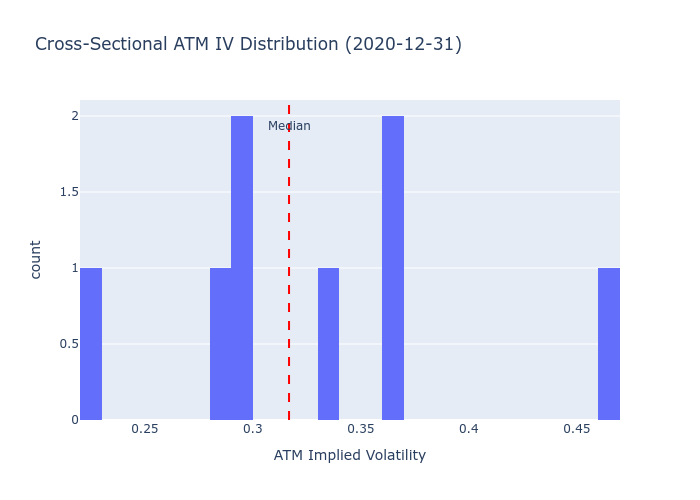

In [19]:
# IV distribution across universe
fig = px.histogram(
    cross_section.to_pandas(),
    x="iv_atm",
    nbins=40,
    title=f"Cross-Sectional ATM IV Distribution ({sample_date})",
    labels={"iv_atm": "ATM Implied Volatility", "count": "Number of Symbols"},
)
median_iv = float(cross_section["iv_atm"].median())
fig.add_vline(x=median_iv, line_dash="dash", line_color="red")
fig.add_annotation(x=median_iv, y=0.95, yref="paper", text="Median", showarrow=False)
fig.show()

## 6. Time Series Analysis

How does IV evolve over time? The year 2020 provides an excellent case study
with the COVID crash in March.

In [20]:
# Daily aggregate IV statistics
daily_iv = (
    converged.with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
    .filter(pl.col("moneyness").is_between(0.98, 1.02))
    .filter(pl.col("call_put") == "C")
    .group_by("timestamp")
    .agg(
        [
            pl.col("implied_vol").mean().alias("iv_mean"),
            pl.col("implied_vol").median().alias("iv_median"),
            pl.col("implied_vol").quantile(0.1).alias("iv_p10"),
            pl.col("implied_vol").quantile(0.9).alias("iv_p90"),
            pl.col("symbol").n_unique().alias("n_symbols"),
        ]
    )
    .sort("timestamp")
)

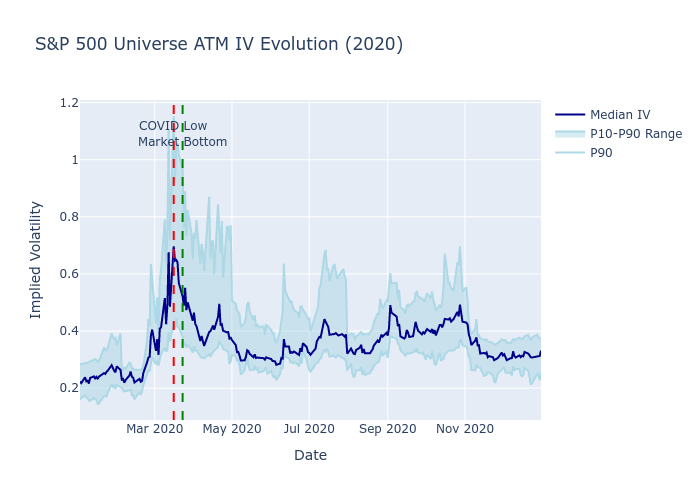

In [21]:
# Build the full IV-evolution figure in one cell — splitting the figure across
# two cells produced an intermediate render with no title or axis labels.
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=daily_iv["timestamp"].to_list(),
        y=daily_iv["iv_p90"].to_list(),
        fill=None,
        mode="lines",
        line_color="lightblue",
        name="P90",
    )
)
fig.add_trace(
    go.Scatter(
        x=daily_iv["timestamp"].to_list(),
        y=daily_iv["iv_p10"].to_list(),
        fill="tonexty",
        mode="lines",
        line_color="lightblue",
        name="P10-P90 Range",
    )
)
fig.add_trace(
    go.Scatter(
        x=daily_iv["timestamp"].to_list(),
        y=daily_iv["iv_median"].to_list(),
        mode="lines",
        line_color="darkblue",
        line_width=2,
        name="Median IV",
    )
)

fig.add_vline(x="2020-03-16", line_dash="dash", line_color="red")
fig.add_vline(x="2020-03-23", line_dash="dash", line_color="green")
fig.add_annotation(x="2020-03-16", y=0.95, yref="paper", text="COVID Low", showarrow=False)
fig.add_annotation(x="2020-03-23", y=0.90, yref="paper", text="Market Bottom", showarrow=False)

fig.update_layout(
    title="S&P 500 Universe ATM IV Evolution (2020)",
    xaxis_title="Date",
    yaxis_title="Implied Volatility",
    height=500,
)
fig.show()

**Key observations:**
- The 90th-percentile ATM IV crossed 100% in mid-March 2020 (peak P90 ≈ 115% on
  2020-03-16); cross-sectional median ATM IV peaked near 70%.
- IV stayed materially above pre-crash levels well past Q1 — slow mean reversion
  even as spot recovered.
- The "fear gauge" aspect of IV — sharp spike, slow decay — is visible even on
  this eight-symbol slice.

## 7. Execution Cost Proxy: Bid-Ask Spreads

Since we don't have volume or open interest, bid-ask spread serves as our
primary liquidity/execution cost indicator.

In [22]:
# Compute spread metrics
spread_analysis = (
    converged.with_columns(
        [
            (pl.col("ask") - pl.col("bid")).alias("spread_abs"),
            ((pl.col("ask") - pl.col("bid")) / pl.col("mid_price")).alias("spread_pct"),
            (pl.col("strike") / pl.col("underlying_price")).alias("moneyness"),
        ]
    )
    .filter(pl.col("mid_price") > 0.10)  # Filter penny options
    .filter(pl.col("spread_pct") < 2.0)  # Filter outliers
)

print("=== Bid-Ask Spread Statistics ===")
spread_analysis.select(["spread_abs", "spread_pct"]).describe()

=== Bid-Ask Spread Statistics ===


statistic,spread_abs,spread_pct
str,f64,f64
"""count""",3.547606e6,3.547606e6
"""null_count""",0.0,0.0
"""mean""",4.780173,0.164237
"""std""",5.242356,0.272971
"""min""",-2.35,-0.153846
"""25%""",0.8,0.029326
"""50%""",3.15,0.064392
"""75%""",8.0,0.160804
"""max""",1250.0,1.99975


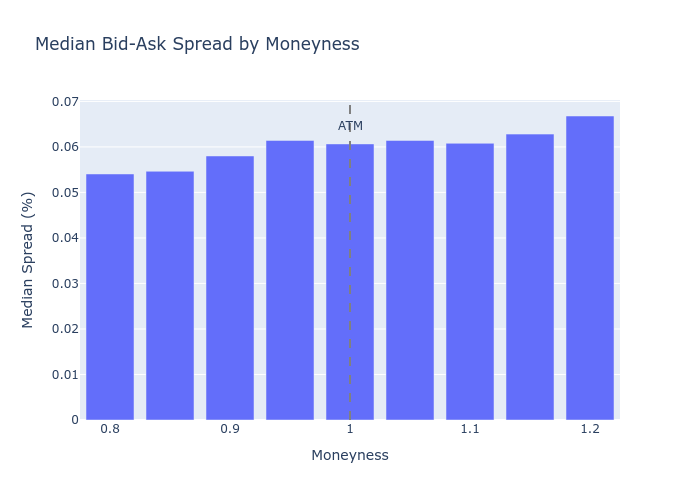

In [23]:
# Spread by moneyness
spread_by_moneyness = (
    spread_analysis.filter(pl.col("moneyness").is_between(0.8, 1.2))
    .with_columns((pl.col("moneyness") * 20).round() / 20)  # Bucket to 5% increments
    .group_by("moneyness")
    .agg([pl.col("spread_pct").median().alias("median_spread")])
    .sort("moneyness")
)

fig = px.bar(
    spread_by_moneyness.to_pandas(),
    x="moneyness",
    y="median_spread",
    title="Median Bid-Ask Spread by Moneyness",
    labels={"moneyness": "Moneyness", "median_spread": "Median Spread (%)"},
)
fig.add_vline(x=1.0, line_dash="dash", line_color="gray")
fig.add_annotation(x=1.0, y=0.95, yref="paper", text="ATM", showarrow=False)
fig.show()

**Spread observations:**
- ATM options have tightest spreads (most liquid)
- Spreads widen for OTM options (less liquid)
- Deep OTM options can have very wide spreads (>50%)
- **Implication**: Focus on near-ATM for tradeable strategies

## 8. Data Quality Assessment

### 8.1 IV Convergence Rates

In [24]:
# Convergence statistics
convergence_stats = (
    options.group_by("iv_convergence")
    .len()
    .with_columns((pl.col("len") / pl.sum("len") * 100).alias("pct"))
    .sort("len", descending=True)
)

print("=== IV Convergence Status ===")
for row in convergence_stats.iter_rows(named=True):
    print(f"  {row['iv_convergence']}: {row['len']:,} ({row['pct']:.2f}%)")

=== IV Convergence Status ===
  Converged: 3,588,121 (69.55%)
  SmallBid_FlatExtrapol: 498,319 (9.66%)
  IntrVal_FlatExtrapol: 492,298 (9.54%)
  IntrVal_PutCallPair: 408,346 (7.92%)
  Failed: 104,718 (2.03%)
  Failed_PutCallPair: 29,418 (0.57%)
  SmallBid_PutCallPair: 14,446 (0.28%)
  IntrVal_LinInterp: 14,324 (0.28%)
  Failed_FlatExtrapol: 8,797 (0.17%)
  Failed_LinInterp: 89 (0.00%)


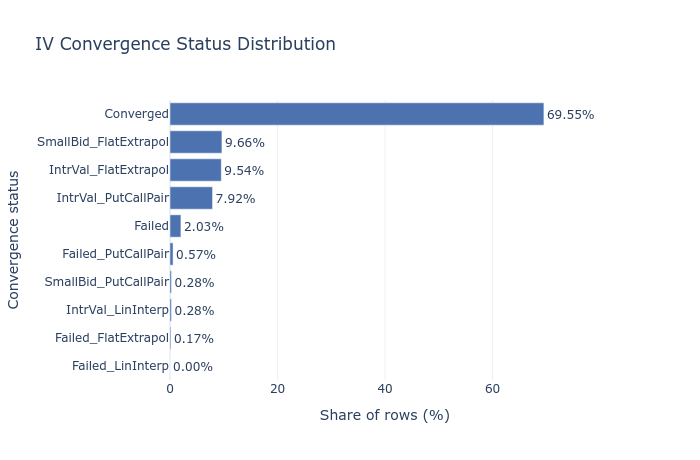

In [25]:
# Horizontal bar chart instead of a pie: 10 convergence categories make a pie
# unreadable (tiny slices overlap their labels). The bar chart sorts by share
# and keeps every label legible.
convergence_pd = convergence_stats.to_pandas().sort_values("pct", ascending=True)
fig = go.Figure(
    data=go.Bar(
        x=convergence_pd["pct"],
        y=convergence_pd["iv_convergence"],
        orientation="h",
        text=[f"{v:.2f}%" for v in convergence_pd["pct"]],
        textposition="outside",
        marker_color="#4C72B0",
    )
)
fig.update_layout(
    title="IV Convergence Status Distribution",
    xaxis_title="Share of rows (%)",
    yaxis_title="Convergence status",
    template="plotly_white",
    height=460,
    margin=dict(l=170, r=100),
    xaxis=dict(range=[0, max(convergence_pd["pct"]) * 1.15]),
)
fig.show()

### 8.2 Coverage Analysis

In [26]:
# Daily symbol coverage
daily_coverage = (
    converged.group_by("timestamp")
    .agg(
        [
            pl.col("symbol").n_unique().alias("n_symbols"),
            pl.len().alias("n_options"),
        ]
    )
    .sort("timestamp")
)

print("=== Daily Coverage (Converged Options) ===")
print(f"Mean symbols/day: {daily_coverage['n_symbols'].mean():.0f}")
print(f"Min symbols/day: {daily_coverage['n_symbols'].min()}")
print(f"Max symbols/day: {daily_coverage['n_symbols'].max()}")

=== Daily Coverage (Converged Options) ===
Mean symbols/day: 8
Min symbols/day: 8
Max symbols/day: 8


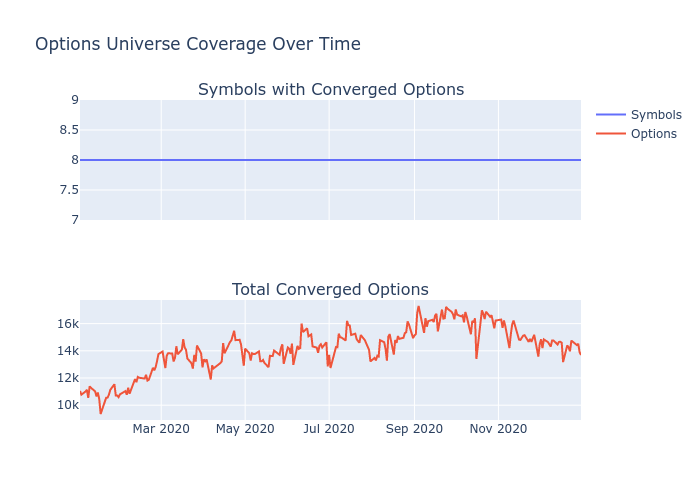

In [27]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=("Symbols with Converged Options", "Total Converged Options"),
)

coverage_pd = daily_coverage.to_pandas()

fig.add_trace(
    go.Scatter(x=coverage_pd["timestamp"], y=coverage_pd["n_symbols"], name="Symbols"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=coverage_pd["timestamp"], y=coverage_pd["n_options"], name="Options"),
    row=2,
    col=1,
)

fig.update_layout(height=500, title="Options Universe Coverage Over Time")
fig.show()

### 8.3 Greeks Validation

In [28]:
print("=== Greeks Validity Checks ===")

checks = converged.select(
    [
        # Delta should be [-1, 1]
        ((pl.col("delta") >= -1.0) & (pl.col("delta") <= 1.0)).mean().alias("delta_in_bounds"),
        # Gamma should be non-negative
        (pl.col("gamma") >= 0).mean().alias("gamma_non_negative"),
        # Vega should be non-negative
        (pl.col("vega") >= 0).mean().alias("vega_non_negative"),
        # Theta typically negative
        (pl.col("theta") <= 0.01).mean().alias("theta_typical"),
        # IV should be positive
        (pl.col("implied_vol") > 0).mean().alias("iv_positive"),
    ]
)

for col in checks.columns:
    pct = checks[col][0] * 100
    status = "PASS" if pct > 99.9 else ("WARN" if pct > 95 else "FAIL")
    print(f"  [{status}] {col}: {pct:.2f}%")

=== Greeks Validity Checks ===
  [PASS] delta_in_bounds: 100.00%
  [PASS] gamma_non_negative: 100.00%
  [PASS] vega_non_negative: 100.00%
  [PASS] theta_typical: 99.97%
  [PASS] iv_positive: 100.00%


In [29]:
print("\n=== Greeks Summary Statistics ===")
converged.select(["delta", "gamma", "theta", "vega", "implied_vol"]).describe()


=== Greeks Summary Statistics ===


statistic,delta,gamma,theta,vega,implied_vol
str,f64,f64,f64,f64,f64
"""count""",3.588121e6,3.588121e6,3.588121e6,3.588121e6,3.588121e6
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.08465,0.007057,-0.488061,2.155491,0.428263
"""std""",0.542994,0.020037,1.034231,2.955213,0.180963
"""min""",-1.0,0.0,-73.25705,0.0,0.04137
"""25%""",-0.29631,0.00043,-0.55531,0.19924,0.32162
"""50%""",-0.0042,0.00119,-0.19009,0.84598,0.38551
"""75%""",0.57121,0.00462,-0.04326,3.04862,0.4867
"""max""",1.0,1.154,0.02716,20.70025,8.91559


### 8.4 Point-in-Time Validation

In [30]:
print("=== Point-in-Time Checks ===")

# Expiration must be >= observation date
exp_check = options.filter(pl.col("expiration") < pl.col("timestamp"))
print(f"Expiration < Date violations: {len(exp_check):,}")

# Days to maturity must be non-negative
dtm_check = options.filter(pl.col("days_to_maturity") < 0)
print(f"Negative days_to_maturity: {len(dtm_check):,}")

if len(exp_check) == 0 and len(dtm_check) == 0:
    print("[OK] PASSED - No look-ahead bias detected")
else:
    print("[FAIL] FAILED - Data integrity issue")

=== Point-in-Time Checks ===
Expiration < Date violations: 0
Negative days_to_maturity: 0
[OK] PASSED - No look-ahead bias detected


## 9. Information Content Preview

Why does options data predict underlying returns? Let's examine the IV-return
relationship.

In [31]:
# Compute ATM IV per symbol/date
atm_iv = (
    converged.with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
    .filter(pl.col("moneyness").is_between(0.98, 1.02))
    .filter(pl.col("call_put") == "C")
    .with_columns((pl.col("moneyness") - 1.0).abs().alias("atm_distance"))
    .sort(["timestamp", "symbol", "atm_distance"])
    .group_by(["timestamp", "symbol"])
    .first()
    .select(["timestamp", "symbol", "implied_vol", "underlying_price"])
    .rename({"implied_vol": "iv_atm"})
)

# Join with daily prices and compute returns
panel = (
    atm_iv.join(
        daily.select(["timestamp", "symbol", "close"]), on=["timestamp", "symbol"], how="inner"
    )
    .sort(["symbol", "timestamp"])
    .with_columns(
        [
            pl.col("iv_atm").shift(5).over("symbol").alias("iv_atm_lag5"),
            pl.col("close").shift(-5).over("symbol").alias("close_fwd5"),
        ]
    )
    .with_columns(
        [
            (pl.col("iv_atm") - pl.col("iv_atm_lag5")).alias("iv_change_5d"),
            ((pl.col("close_fwd5") / pl.col("close")) - 1).alias("ret_fwd5"),
        ]
    )
    .drop_nulls(subset=["iv_change_5d", "ret_fwd5"])
)

# Correlation
correlation = panel.select(pl.corr("iv_change_5d", "ret_fwd5").alias("corr"))[0, 0]
print("=== IV Change vs Forward Return ===")
print(f"Correlation: {correlation:.4f}")
print("Interpretation: Falling IV tends to precede positive returns")

=== IV Change vs Forward Return ===
Correlation: -0.0814
Interpretation: Falling IV tends to precede positive returns


In [32]:
# Quintile analysis
panel_ranked = (
    panel.with_columns(pl.col("iv_change_5d").rank().over("timestamp").alias("iv_rank_raw"))
    .with_columns(
        (pl.col("iv_rank_raw") / pl.col("iv_rank_raw").max().over("timestamp") * 100).alias(
            "iv_pct"
        )
    )
    .with_columns(
        pl.when(pl.col("iv_pct") <= 20)
        .then(1)
        .when(pl.col("iv_pct") <= 40)
        .then(2)
        .when(pl.col("iv_pct") <= 60)
        .then(3)
        .when(pl.col("iv_pct") <= 80)
        .then(4)
        .otherwise(5)
        .alias("iv_quintile")
    )
)

quintile_returns = (
    panel_ranked.group_by("iv_quintile")
    .agg(
        [
            pl.col("ret_fwd5").mean().alias("mean_ret"),
            pl.col("ret_fwd5").std().alias("std_ret"),
            pl.len().alias("n_obs"),
        ]
    )
    .sort("iv_quintile")
)

print("\n=== Forward Returns by IV Change Quintile ===")
print("(Q1 = largest IV decrease, Q5 = largest IV increase)")
quintile_returns


=== Forward Returns by IV Change Quintile ===
(Q1 = largest IV decrease, Q5 = largest IV increase)


iv_quintile,mean_ret,std_ret,n_obs
i32,f64,f64,u32
1,0.010277,0.082509,243
2,0.003726,0.059334,486
3,0.000134,0.083193,243
4,-0.001231,0.069892,486
5,0.00073,0.108666,486


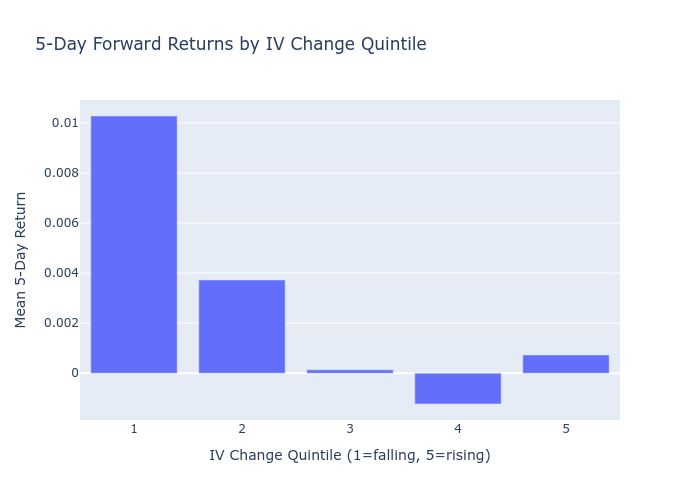

In [33]:
fig = px.bar(
    quintile_returns.to_pandas(),
    x="iv_quintile",
    y="mean_ret",
    title="5-Day Forward Returns by IV Change Quintile",
    labels={
        "iv_quintile": "IV Change Quintile (1=falling, 5=rising)",
        "mean_ret": "Mean 5-Day Return",
    },
)
fig.update_layout(xaxis=dict(tickmode="array", tickvals=[1, 2, 3, 4, 5]))
fig.show()

The sign of the −0.08 IV-change vs forward-return correlation is negative: on
this 8-symbol 2020 slice, larger IV declines line up with higher 5-day forward
returns and larger IV increases with lower forward returns. The quintile means
above show how monotonic the relationship is. This notebook does not test
statistical significance or out-of-sample stability; the IV-based feature is
evaluated rigorously via IC analysis in Chapter 9.

## 10. Data Quality Summary

In [34]:
total_rows = len(options)
converged_rows = len(converged)
converged_pct = converged_rows / total_rows * 100

print("=" * 70)
print("DATA QUALITY SUMMARY: S&P 500 OPTIONS")
print("=" * 70)

print("\n1. SCALE")
print(f"   Total options records: {total_rows:,}")
print(f"   Converged IV records: {converged_rows:,} ({converged_pct:.1f}%)")
print(f"   Unique underlyings: {options['symbol'].n_unique()}")
print(f"   Date range: {options['timestamp'].min()} to {options['timestamp'].max()}")

print("\n2. COVERAGE")
print(f"   Trading days: {daily_coverage['timestamp'].n_unique()}")
print(f"   Avg symbols/day: {daily_coverage['n_symbols'].mean():.0f}")
print(f"   Avg options/symbol/day: {options_per_symbol['n_options'].mean():.0f}")

print("\n3. DATA QUALITY")
print(f"   Point-in-time: {'PASS' if len(exp_check) == 0 else 'FAIL'}")
print("   Greeks validity: See checks above")
print(f"   Convergence rate: {converged_pct:.1f}%")

print("\n4. EXECUTION PROXY")
print(
    f"   Median ATM spread: {spread_by_moneyness.filter(pl.col('moneyness') == 1.0)['median_spread'][0]:.1%}"
)

print("\n5. INFORMATION CONTENT")
print(f"   IV-Return Correlation: {correlation:.4f}")

print("\n" + "=" * 70)
print("DATASET SUPPORTS TWO CASE STUDIES:")
print("  sp500_equity_option_analytics — IV features used to trade equities")
print("  sp500_options                  — short-straddle harvest with daily delta hedge")
print("=" * 70)

DATA QUALITY SUMMARY: S&P 500 OPTIONS

1. SCALE
   Total options records: 5,158,876
   Converged IV records: 3,588,121 (69.6%)
   Unique underlyings: 8
   Date range: 2020-01-02 to 2020-12-31

2. COVERAGE
   Trading days: 253
   Avg symbols/day: 8
   Avg options/symbol/day: 2549

3. DATA QUALITY
   Point-in-time: PASS
   Greeks validity: See checks above
   Convergence rate: 69.6%

4. EXECUTION PROXY
   Median ATM spread: 6.1%

5. INFORMATION CONTENT
   IV-Return Correlation: -0.0814

DATASET SUPPORTS TWO CASE STUDIES:
  sp500_equity_option_analytics — IV features used to trade equities
  sp500_options                  — short-straddle harvest with daily delta hedge


## Key Takeaways

1. **Scale (EDA slice)**: ~5.2M option records across 8 representative S&P 500
   underlyings in 2020. The full AlgoSeek panel covers the broader index — this
   notebook intentionally subsamples for fast exploration.
2. **Structure**: Each underlying carries dozens of expirations and 100+
   strikes per day; chains are 3-D grids (strike × expiration × call/put).
3. **Quality**: 69.6% of rows carry `iv_convergence == "Converged"`. The other
   convergence codes flag extrapolated or solver-failed IVs and should be
   excluded from analysis.
4. **Greeks**: Pre-computed Black-Scholes sensitivities are well-bounded — Δ in
   [-1, 1], Γ ≥ 0, ν ≥ 0, θ ≤ 0 — at >99.9% of converged rows.
5. **Volatility Surface**: Smile, skew, and term structure are all visible on
   this slice; the 3-D surface compresses both axes into one plot.
6. **Information**: 5-day IV changes correlate with 5-day forward equity
   returns at -0.08 on this sample (falling IV → positive returns), motivating
   the IV-based features in Chapter 8.
7. **Execution**: Median ATM bid-ask spread is ~6%; deep-OTM spreads widen
   sharply, which constrains tradeable strategies to near-the-money strikes.

## Data Limitations

- **No volume/open interest**: Cannot filter for liquidity directly.
- **Daily snapshots only**: No intraday dynamics for gamma scalping.
- **Spread as proxy**: Bid-ask is the only execution cost indicator available.

## Next Steps

- `08_options_greeks_computation`: Compute Greeks from scratch and validate
  against the vendor numbers used here.
- Chapter 8: Build IV surface features for ML.
- Chapter 9: Model-based feature extraction (PCA, autoencoders).
- Chapter 12: ML models for equity and options targets.
- Chapter 16: Backtests using these features.